# Model Construction

In [2]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path

In [3]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [4]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VAL_CSV = DATA_DIR / "validate_split.csv"
TEST_CSV = DATA_DIR / "test_split.csv"

CLASSES = ["malignant", "benign", "normal"]
label_map = {c: i for i, c in enumerate(CLASSES)}

## Retrive images 

In [5]:
def merge_masks_pil(img_path):
    root, ext = os.path.splitext(img_path)
    mask_paths = glob.glob(f"{root}_mask*.png")
    
    img = np.array(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    
    if not mask_paths:
        return np.zeros((h, w), dtype=np.uint8)
    
    merged = None
    for mpath in mask_paths:
        m = np.array(Image.open(mpath).convert("L"))
        if m.shape != (h, w):
            m = np.array(Image.fromarray(m).resize((w, h), Image.NEAREST))
        m = (m > 0).astype(np.uint8)
        merged = m if merged is None else np.maximum(merged, m)
    
    return merged

class BUSIDataset(Dataset):
    def __init__(self, csv_file, label_map, transform=None, use_masks=True, is_training=False):
        self.df = pd.read_csv(csv_file)
        self.label_map = label_map
        self.transform = transform
        self.use_masks = use_masks
        self.is_training = is_training
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        label_str = self.df.iloc[idx]['label']
        
        img_rgb = Image.open(img_path).convert('RGB')
        
        if self.use_masks:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = img_rgb.convert('L')
            
            if self.is_training:
                if np.random.random() < 0.5:
                    img_gray = img_gray.transpose(Image.FLIP_LEFT_RIGHT)
                    mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
                
                angle = np.random.uniform(-15, 15)
                img_gray = img_gray.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
                mask_pil = mask_pil.rotate(angle, resample=Image.NEAREST, fillcolor=0)
                
                translate_x = np.random.uniform(-0.15, 0.15) * img_gray.size[0]
                translate_y = np.random.uniform(-0.15, 0.15) * img_gray.size[1]
                img_gray = img_gray.transform(
                    img_gray.size, Image.AFFINE, 
                    (1, 0, translate_x, 0, 1, translate_y),
                    fillcolor=0
                )
                mask_pil = mask_pil.transform(
                    mask_pil.size, Image.AFFINE,
                    (1, 0, translate_x, 0, 1, translate_y),
                    fillcolor=0
                )
                
                scale = np.random.uniform(0.9, 1.1)
                orig_w, orig_h = img_gray.size
                new_size = (int(orig_w * scale), int(orig_h * scale))
                img_gray = img_gray.resize(new_size, Image.LANCZOS)
                mask_pil = mask_pil.resize(new_size, Image.NEAREST)
                
                if scale > 1.0:
                    left = (new_size[0] - orig_w) // 2
                    top = (new_size[1] - orig_h) // 2
                    img_gray = img_gray.crop((left, top, left + orig_w, top + orig_h))
                    mask_pil = mask_pil.crop((left, top, left + orig_w, top + orig_h))
                else:
                    new_img = Image.new('L', (orig_w, orig_h), 0)
                    new_mask = Image.new('L', (orig_w, orig_h), 0)
                    paste_x = (orig_w - new_size[0]) // 2
                    paste_y = (orig_h - new_size[1]) // 2
                    new_img.paste(img_gray, (paste_x, paste_y))
                    new_mask.paste(mask_pil, (paste_x, paste_y))
                    img_gray = new_img
                    mask_pil = new_mask
            
            img_gray = img_gray.resize((224, 224), Image.LANCZOS)
            mask_pil = mask_pil.resize((224, 224), Image.NEAREST)
            
            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)
            
            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)
            
            img = torch.cat([img_gray_t, mask_t], dim=0)
        else:
            img = img_rgb.convert('L')
            if self.transform:
                img = self.transform(img)
        
        label = self.label_map[label_str]
        return img, label

In [6]:
BATCH_SIZE = 32
USE_MASKS = True

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = BUSIDataset(TRAIN_CSV, label_map, transform=train_transform, use_masks=USE_MASKS, is_training=True)
val_dataset = BUSIDataset(VAL_CSV, label_map, transform=transform, use_masks=USE_MASKS, is_training=False)
test_dataset = BUSIDataset(TEST_CSV, label_map, transform=transform, use_masks=USE_MASKS, is_training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## CNN model for ML

In [7]:
class BreastUS_CNN(nn.Module):
    def __init__(self, num_classes=3, input_channels=2):
        super(BreastUS_CNN, self).__init__()
        self.input_channels = input_channels
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)

class_to_idx = {name: idx for idx, name in enumerate(CLASSES)}
standard_weights = np.zeros(len(CLASSES))
for class_name, count in class_counts.items():
    idx = class_to_idx[class_name]
    standard_weights[idx] = total_samples / (len(CLASSES) * count)

normal_idx = class_to_idx['normal']
malignant_idx = class_to_idx['malignant']

class_weights = standard_weights.copy()
class_weights[normal_idx] = standard_weights[normal_idx] * 1.6
class_weights[malignant_idx] = standard_weights[malignant_idx] * 1.3

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = FocalLoss(alpha=class_weights_tensor, gamma=1.5, reduction='mean')

In [9]:
def compute_correct_labels(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = torch.sum(preds == labels).item()
    total = labels.size(0)
    return correct, total


In [10]:
def training_loop(model, optimizer, scheduler, num_epochs, train_loader, val_loader, test_loader, class_names):
    train_losses, val_losses, test_losses = [], [], []
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_class_correct = {i: 0 for i in range(len(class_names))}
        val_class_total = {i: 0 for i in range(len(class_names))}
        
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == y).sum().item()
                val_total += y.size(0)
                
                for i in range(len(y)):
                    label = y[i].item()
                    pred = preds[i].item()
                    val_class_total[label] += 1
                    if label == pred:
                        val_class_correct[label] += 1

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total

        model.eval()
        test_loss = 0
        
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                test_loss += loss.item()

        avg_test_loss = test_loss / len(test_loader)
        
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        val_class_accs = []
        for i in range(len(class_names)):
            if val_class_total.get(i, 0) > 0:
                val_class_accs.append(val_class_correct[i] / val_class_total[i])
        
        if len(val_class_accs) == len(class_names):
            min_class_acc = min(val_class_accs)
            balanced_score = val_acc * (0.7 + 0.3 * min_class_acc)
        else:
            balanced_score = val_acc
        
        if balanced_score > best_val_acc:
            best_val_acc = balanced_score
            best_model_state = model.state_dict().copy()

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        test_losses.append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, test_losses


In [11]:
input_channels = 2 if USE_MASKS else 1
model = BreastUS_CNN(num_classes=3, input_channels=input_channels).to(device)

initial_lr = 5e-4
optimizer = optim.Adam(model.parameters(), lr=initial_lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, verbose=False, min_lr=1e-6
)

EPOCHS = 50
train_losses, val_losses, test_losses = training_loop(
    model, optimizer, scheduler, EPOCHS, train_loader, val_loader, test_loader, CLASSES)

/opt/miniconda3/envs/cs171/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/50] Train Loss: 1.0531 | Val Loss: 1.3112 | Test Loss: 1.3508
Epoch [2/50] Train Loss: 0.8981 | Val Loss: 1.0875 | Test Loss: 1.0906
Epoch [3/50] Train Loss: 0.8337 | Val Loss: 1.2547 | Test Loss: 1.1945
Epoch [4/50] Train Loss: 0.8409 | Val Loss: 1.5438 | Test Loss: 1.4658
Epoch [5/50] Train Loss: 0.7249 | Val Loss: 1.3250 | Test Loss: 1.6111
Epoch [6/50] Train Loss: 0.6881 | Val Loss: 3.9460 | Test Loss: 3.8288
Epoch [7/50] Train Loss: 0.5568 | Val Loss: 3.1123 | Test Loss: 3.0411
Epoch [8/50] Train Loss: 0.5289 | Val Loss: 1.5325 | Test Loss: 1.5064
Epoch [9/50] Train Loss: 0.4353 | Val Loss: 1.7557 | Test Loss: 1.6309
Epoch [10/50] Train Loss: 0.4160 | Val Loss: 4.8033 | Test Loss: 4.7449
Epoch [11/50] Train Loss: 0.4148 | Val Loss: 1.7147 | Test Loss: 1.6473
Epoch [12/50] Train Loss: 0.3351 | Val Loss: 1.0533 | Test Loss: 0.9110
Epoch [13/50] Train Loss: 0.2974 | Val Loss: 0.6684 | Test Loss: 0.6165
Epoch [14/50] Train Loss: 0.3004 | Val Loss: 0.5590 | Test Loss: 0.4958
E

All the losses are decreasing rapidly, but the accuracy is still low.  

In [12]:
def evaluate_model(model, test_loader, device, class_names):
    """Evaluate model on test set and return accuracy and predictions."""
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    # Per-class statistics
    class_correct = {i: 0 for i in range(len(class_names))}
    class_total = {i: 0 for i in range(len(class_names))}
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
            correct += (preds == y).sum().item()
            total += y.size(0)
            
            # Count per-class accuracy
            for i in range(len(y)):
                label = y[i].item()
                pred = preds[i].item()
                class_total[label] += 1
                if label == pred:
                    class_correct[label] += 1
    
    accuracy = correct / total
    print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")
    print("\nPer-class Test Accuracy:")
    for i, class_name in enumerate(class_names):
        if class_total[i] > 0:
            class_acc = class_correct[i] / class_total[i] * 100
            print(f"  {class_name}: {class_correct[i]}/{class_total[i]} ({class_acc:.2f}%)")
    
    return np.array(all_preds), np.array(all_labels)

# Evaluate the trained model
test_preds, test_labels = evaluate_model(model, test_loader, device, CLASSES)



Overall Test Accuracy: 85.90%

Per-class Test Accuracy:
  malignant: 39/42 (92.86%)
  benign: 68/87 (78.16%)
  normal: 27/27 (100.00%)


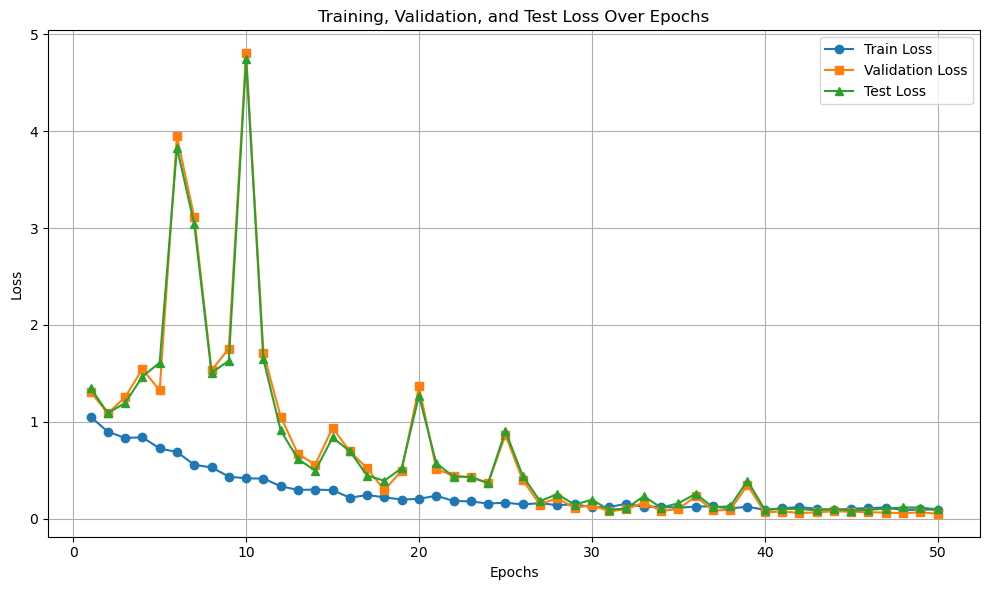

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, 's-', label='Validation Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, '^-', label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training, Validation, and Test Loss Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

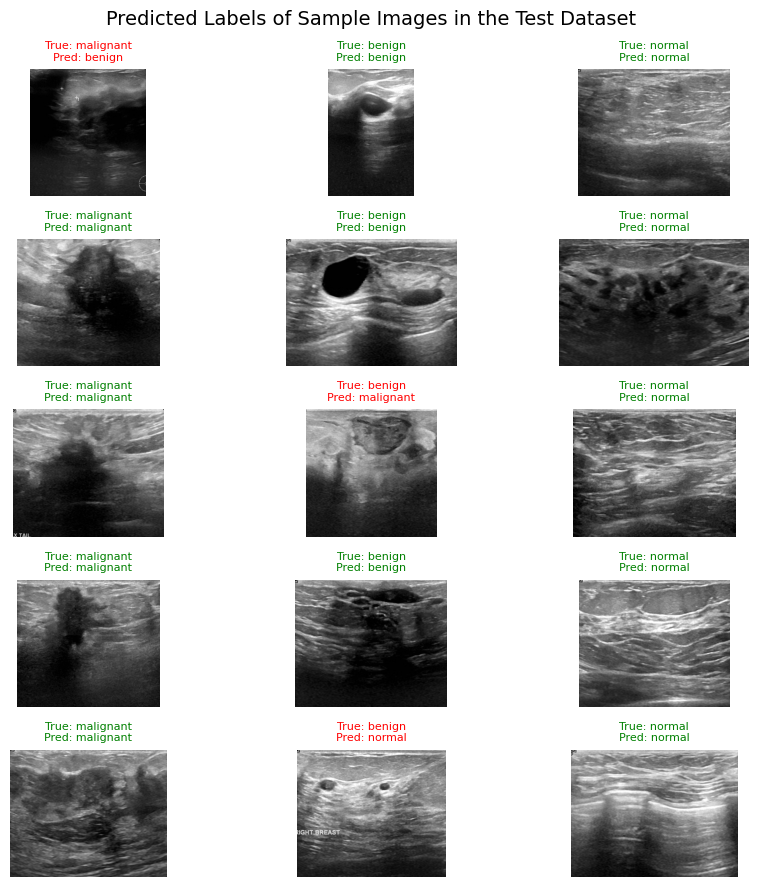

In [14]:
model.eval()
test_df = pd.read_csv(TEST_CSV)

num_samples_per_class = 5
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(num_samples_per_class, len(CLASSES))

reverse_label_map = {v: k for k, v in label_map.items()}

for class_idx, class_name in enumerate(CLASSES):
    class_images = test_df[test_df['label'] == class_name].head(num_samples_per_class)
    
    for row_idx, (_, row) in enumerate(class_images.iterrows()):
        img_path = row['path']
        image = Image.open(img_path).convert('RGB')
        
        if USE_MASKS:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = image.convert('L')
            
            img_gray = img_gray.resize((224, 224), Image.LANCZOS)
            mask_pil = mask_pil.resize((224, 224), Image.NEAREST)
            
            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)
            
            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)
            
            input_tensor = torch.cat([img_gray_t, mask_t], dim=0).unsqueeze(0).to(device)
        else:
            img_gray = image.convert('L')
            input_tensor = transform(img_gray).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = torch.max(output, 1)
        predicted_class = reverse_label_map[predicted.item()]
        true_label = row['label']
        
        ax = fig.add_subplot(gs[row_idx, class_idx])
        ax.imshow(image)
        ax.axis('off')
        
        color = 'green' if predicted_class == true_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {predicted_class}', 
                     color=color, fontsize=8)

plt.suptitle('Predicted Labels of Sample Images in the Test Dataset', fontsize=14)
plt.tight_layout()
plt.show()


The model is doing really well on normal images, but it still need to correctly differentiate between Malignant and Benign tumors. 